This notebook analyzes and generates plots from `results.df`, which contains various measurements of various clustering methods run on all 1070 Scottish elections.

The notebook contains 7 rows for each of the 1070 elections, one for each of 7 clustering methods.
It has the following columns:
- "filename"
- "num_cands"
- "num_voters"
- "num_unique_ballots"
- "avg_ballot_len"
- "ballot_lengths" = list reporting the number of ballots of each length between 0 and num_cands.
- "parties" = list of party abreviations of the candidates.
- "method" = one of {"meanBC", "meanBA", "meanH", "medoBC", "medoBA", "medoH", "slate"}
- "block_size" = fraction of the ballots in first bloc.
- "sil" = silhouette score (all scores are with respect to HH embedding)
- "cal" = calinski harabasz score
- "dav" = davies bouldin score
- "centers" = dictionary {0:center0,1:center1} where "center" means centroid/medoid/slate, depending on the method.
- "clustering" = {0:cluster0,1:cluster1} where each cluster is a dictionary matching ballots to weights.
- "method_closeness" (None except in the slate row of each election): dictionary matching pairs of methods to the difference between the partitions resulting by aplying those methods to that election.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import MDS 
import glob
import math
import re
from Clustering_Functions import *

In [2]:
df = pd.read_pickle('results.pkl')

In [3]:
# add 'party_codes' column containing only the abreviated codes of the parties in the election
# also create a dictionary, called party_dict, matching party codes to party full names
# (including all parties in all elections)

def Party_code_and_fullname(input_string):
    start_idx = input_string.find('(')
    end_idx = input_string.find(')')
    if start_idx != -1 and end_idx != -1:
        A = input_string[start_idx + 1:end_idx]
        B = input_string[:start_idx].strip() + input_string[end_idx + 1:].strip()
        return A, B
    else:
        return None, input_string

party_dict = dict()

for index in df.index:
    pdict = df['parties'][index]
    for party in pdict.values():
        code,full_name = Party_code_and_fullname(party)
        # first check for codes associated to more than one full name.
        if code in party_dict.keys():
            if party_dict[code] != party:
                raise Exception(code, full_name, party_dict[code])
        else:
            party_dict[code] = party

ls = []
for index in df.index:
    parties = df['parties'][index]
    codes = {cand_num:Party_code_and_fullname(full_party_name)[0]  for cand_num,full_party_name in parties.items()}
    ls.append(codes)
df['party_codes']=ls

In [4]:
# add column 'portion_of_complete_ballots' and 'portion_almost_complete_ballots'
l_complete = []
l_almost = []
for index in df.index:
    complete = df['ballot_lengths'][index][df['num_cands'][index]]/df['num_voters'][index]
    almost = df['ballot_lengths'][index][df['num_cands'][index]-1]/df['num_voters'][index]
    l_complete.append(complete)
    l_almost.append(almost)
df['portion_complete_ballots'] = l_complete
df['portion_almost_complete_ballots'] = l_almost

In [5]:
# add column 'bloc_size' = minimum of the two bloc sizes.
ls = []
for row in range(len(df)):
    ls.append(min(df['block_size'][row],1-df['block_size'][row]))
df['bloc_size'] = ls

In [6]:
def parse_filename(filename):
    # Split the filename and remove the '.csv' extension
    parts = filename[:-4].split('_')
    
    # Find the year, which is a 4-digit number
    for i, part in enumerate(parts):
        if part.isdigit() and len(part) == 4:
            year_index = i
            break
    else:
        return None  # Return None if no 4-digit year is found

    # Join parts before the year as location and parts after the year as sublocation
    location = ' '.join(parts[:year_index])
    year = int(parts[year_index])
    sublocation = ' '.join(parts[year_index + 1:])
    
    return location, year, sublocation

In [7]:
# add columns 'year','location', 'sublocation' from the separate parts of the filename

def parse_filename(filename):
    # Split the filename and remove the '.csv' extension
    parts = filename[:-4].split('_')
    
    # Find the year, which is a 4-digit number
    for i, part in enumerate(parts):
        if part.isdigit() and len(part) == 4:
            year_index = i
            break
    else:
        return None  # Return None if no 4-digit year is found

    # Join parts before the year as location and parts after the year as sublocation
    location = ' '.join(parts[:year_index])
    year = int(parts[year_index])
    sublocation = ' '.join(parts[year_index + 1:])
    
    return location, year, sublocation

ls_location = []
ls_year = []
ls_ward = []
for index in df.index:
    location, year, ward = parse_filename(df['filename'][index])
    ls_location.append(location)
    ls_year.append(year)
    ls_ward.append(ward)
df['location'] = ls_location
df['year'] = ls_year
df['ward'] = ls_ward

In [8]:
# list of elections, list of clustering methods
filenames = df['filename'].unique()
method_list = df['method'].unique()

In [10]:
dfs = df[df['method']=='slate'] # only the slate trial of each election
# note that dfs has one row for each election, and hense is good for gathering data that doesn't involve clustering.

In [11]:
len(dfs), len(df)

(1070, 7490)

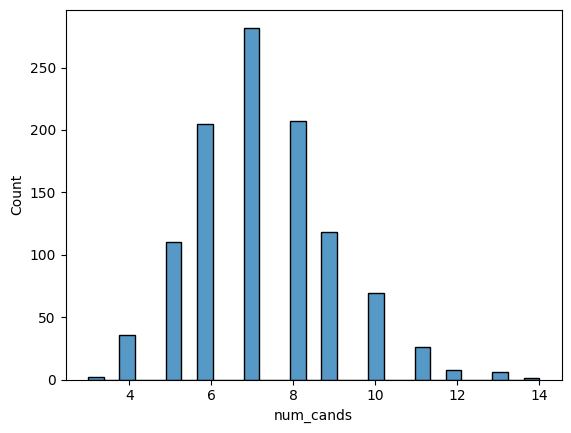

In [12]:
fig = sns.histplot(dfs['num_cands'])
fig.figure.savefig("plots/num_cands.jpg", dpi = 600)

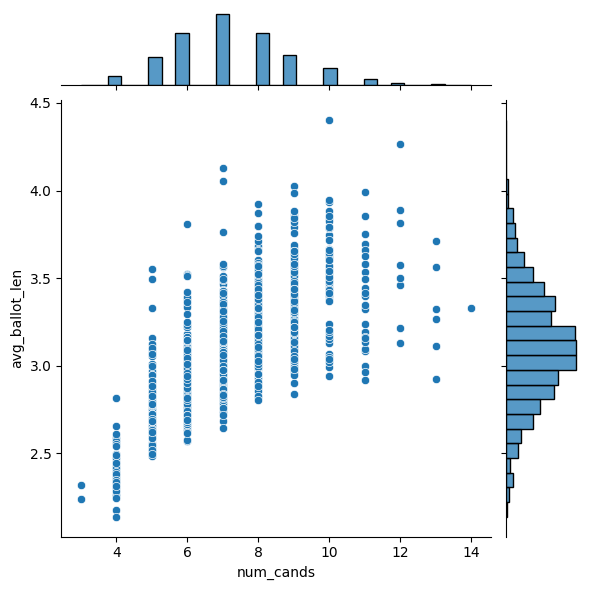

In [13]:
fig = sns.jointplot(dfs, x='num_cands', y='avg_ballot_len')
fig.figure.savefig("plots/num_cands_vs_bal_len.jpg", dpi = 600)

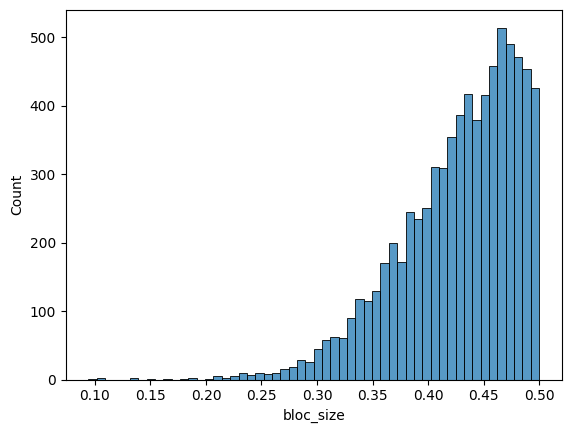

In [14]:
fig = sns.histplot(data = df, x = 'bloc_size')
fig.figure.savefig("plots/block_size.jpg", dpi = 600)

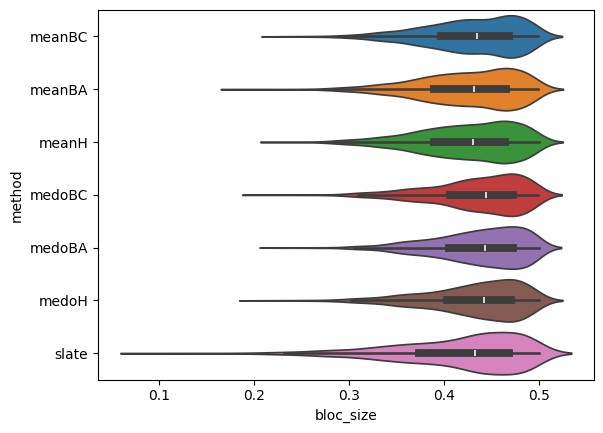

In [15]:
fig = sns.violinplot(data = df, x = 'bloc_size', y='method', hue='method')
fig.figure.savefig("plots/sperm_race.jpg", dpi = 600)

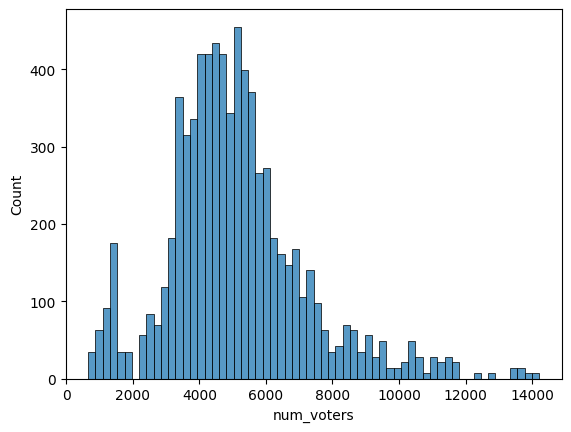

In [16]:
fig = sns.histplot(data=df, x = 'num_voters')
fig.figure.savefig("plots/num_voters.jpg", dpi = 600)

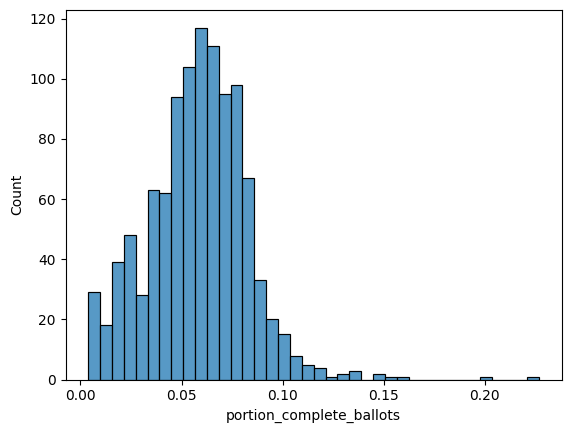

In [17]:
fig = sns.histplot(data = dfs, x = 'portion_complete_ballots')
fig.figure.savefig("plots/portion_complete_ballots.jpg", dpi = 600)

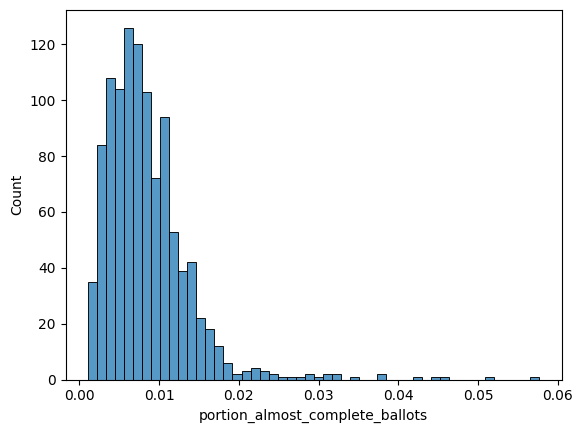

In [18]:
fig = sns.histplot(data = dfs, x = 'portion_almost_complete_ballots')
fig.figure.savefig("plots/portion_almost_complete_ballots.jpg", dpi = 600)

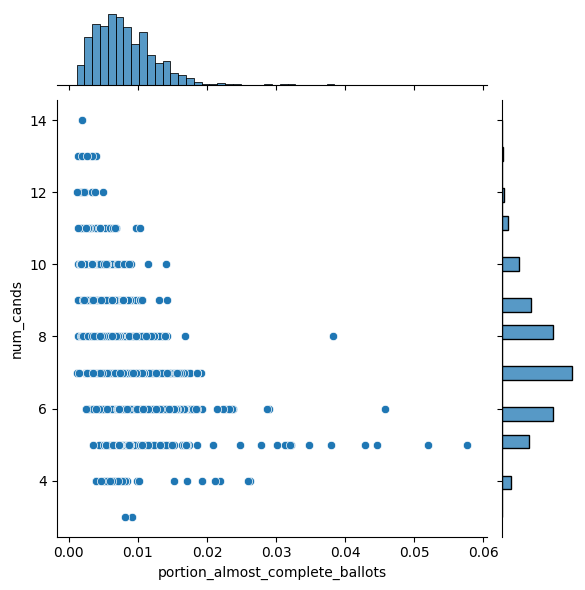

In [19]:
fig = sns.jointplot(data = dfs, x = 'portion_almost_complete_ballots', y='num_cands')
fig.figure.savefig("plots/num_cands_vs_almost_complete.jpg", dpi = 600)

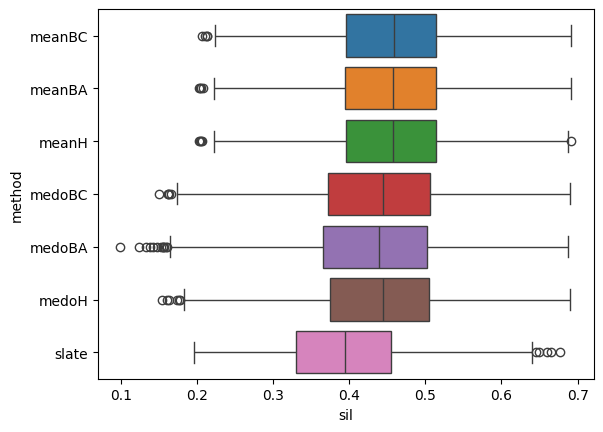

In [22]:
fig = sns.boxplot(data=df, x='sil',y='method', hue = 'method')
fig.figure.savefig("plots/sil.jpg", dpi = 600)

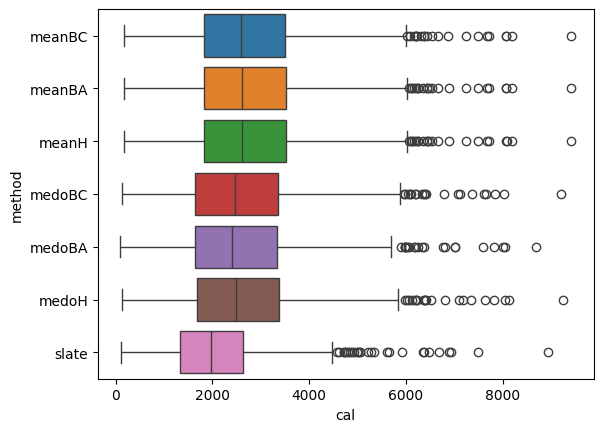

In [23]:
fig = sns.boxplot(data=df, x='cal',y='method', hue = 'method')
fig.figure.savefig("plots/cal.jpg", dpi = 600)

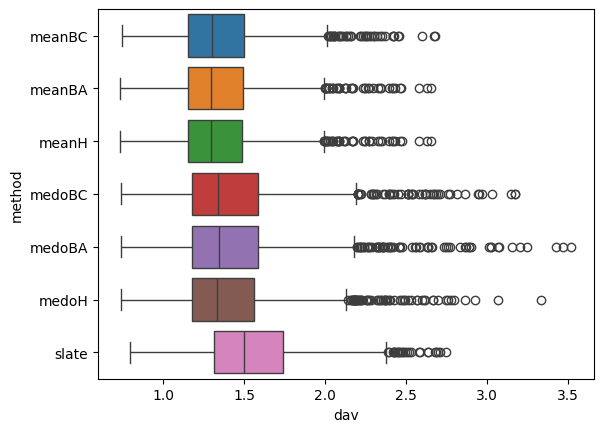

In [24]:
fig = sns.boxplot(data=df, x='dav',y='method', hue = 'method')
fig.figure.savefig("plots/dav.jpg", dpi = 600)

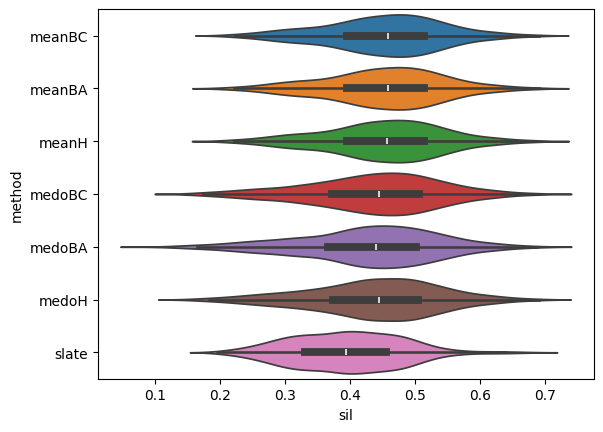

In [25]:
fig = sns.violinplot(data=df, x = 'sil', y = 'method', hue = 'method')
fig.figure.savefig("plots/methd_vs_sil_violin.jpg", dpi = 600)

<Axes: xlabel='year', ylabel='Count'>

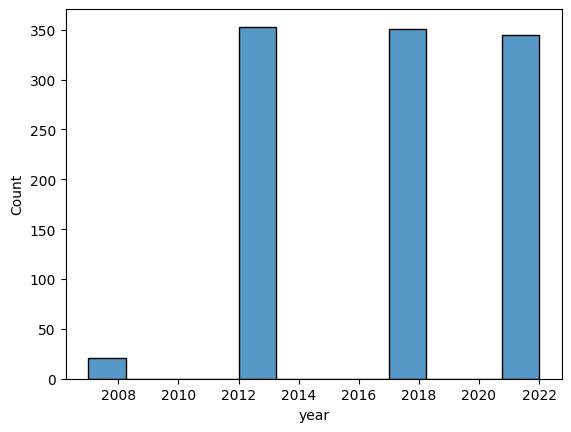

In [26]:
sns.histplot(dfs,x='year')

In [27]:
dfs['year'].unique()

array([2017, 2022, 2012, 2007], dtype=int64)

In [28]:
dfs['location'].unique() # The 32 "Council Areas", also called "Local Authority Areas"

array(['aberdeen', 'aberdeenshire', 'angus', 'argyll bute', 'dumgal',
       'dundee', 'east renfrewshire', 'edinburgh', 'eilean siar',
       'falkirk', 'fife', 'glasgow', 'highland', 'moray',
       'north ayrshire', 'north lanarkshire', 'renfrewshire',
       'south lanarkshire', 'stirling', 'west lothian', 'orkney',
       'clackmannanshire', 'east ayrshire', 'east dunbartonshire',
       'midlothian', 'sc borders', 'shetland', 'south ayrshire',
       'east lothian', 'inverclyde', 'perth kinross',
       'west dunbartonshire'], dtype=object)

In [29]:
compare_methods = pd.DataFrame(index=method_list,columns=method_list)

for m1 in method_list:
    for m2 in method_list:
        running_sum = 0
        for index in dfs.index:
            D = dfs['method_closeness'][index]
            running_sum += D[(m1,m2)]
        compare_methods[m1][m2] = running_sum/len(dfs)

In [30]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
compare_methods

,meanBC,meanBA,meanH,medoBC,medoBA,medoH,slate
meanBC,0.000,0.016,0.017,0.070,0.083,0.070,0.160
meanBA,0.016,0.000,0.004,0.071,0.081,0.070,0.162
meanH,0.017,0.004,0.000,0.071,0.081,0.069,0.163
medoBC,0.070,0.071,0.071,0.023,0.063,0.040,0.175
medoBA,0.083,0.081,0.081,0.063,0.016,0.059,0.179
medoH,0.070,0.070,0.069,0.040,0.059,0.020,0.170
slate,0.160,0.162,0.163,0.175,0.179,0.170,0.000


In [31]:
# Euclidean distance between centroids (dictionaries), summed over the two partition pieces
# wrt the best match between the two pieces of the first clustering and of the second.

def Distance_between_centroids(C1,C2):
    d1 = np.linalg.norm(C1[0]-C2[0]) + np.linalg.norm(C1[1]-C2[1])
    d2 = np.linalg.norm(C1[0]-C2[1]) + np.linalg.norm(C1[1]-C2[0])
    return min(d1,d2)

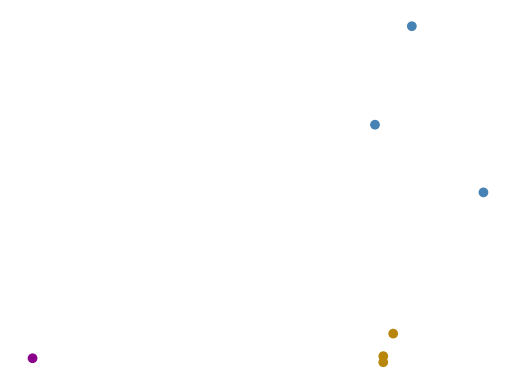

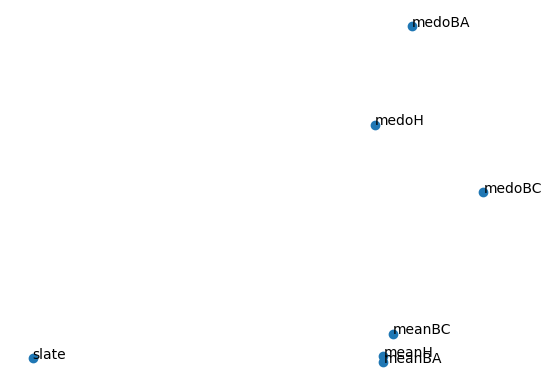

In [32]:
projections = MDS(n_components=2, dissimilarity='precomputed').fit_transform(compare_methods)
X = np.array([p[0] for p in projections])
Y = np.array([p[1] for p in projections])

fig, ax = plt.subplots()
ax.scatter(X,Y, c = ['darkgoldenrod','darkgoldenrod','darkgoldenrod','steelblue','steelblue','steelblue','darkmagenta'])
ax.grid(False)
ax.axis('off')
plt.savefig("plots/method_MDS_unlabled", dpi = 600)
plt.show()


fig, ax = plt.subplots()
ax.scatter(X,Y)
for count in range(len(method_list)):
    ax.annotate(method_list[count], xy=(X[count], Y[count]))
ax.grid(False)
ax.axis('off')
plt.savefig("plots/method_MDS_labeled", dpi = 600)
plt.show()

In [18]:
# Next we'll compare the clustering methods with distance measured as the
# portion of elections in which the centroids are NOT exacty the same.

same_centroids = pd.DataFrame(index = method_list, columns=method_list)

proxy = 'centroids_B'
for m1 in method_list:
    for m2 in method_list:
        #print(m1,m2)
        if m1==m2:
            i1,i2 = 0,1
        else:
            i1,i2 = 0,0
        dif_count = 0
        for filename in filenames:
            dfr = df[(df['filename']==filename) & (df['method'] == m1)]
            indices = dfr.index
            C1 = dfr[proxy][indices[i1]]
            
            dfr = df[(df['filename']==filename) & (df['method'] == m2)]
            indices = dfr.index
            C2 = dfr[proxy][indices[i2]]           
        
            dist =  Distance_between_centroids(C1,C2)
            if dist != 0:
                dif_count +=1
            
        same_centroids[m1][m2] = dif_count/len(filenames)
same_centroids.to_csv('tables\same_centroids.csv')
same_centroids      

,meanBC,meanBA,meanH,medoBC,medoBA,medoH,slate
meanBC,0.035514,0.972897,0.976636,1.0,1.0,0.999065,0.998131
meanBA,0.972897,0.025234,0.88785,1.0,1.0,1.0,0.998131
meanH,0.976636,0.88785,0.027103,1.0,1.0,0.999065,0.998131
medoBC,1.0,1.0,1.0,0.085981,1.0,0.992523,0.999065
medoBA,1.0,1.0,1.0,1.0,0.053271,1.0,1.0
medoH,0.999065,1.0,0.999065,0.992523,1.0,0.064486,1.0
slate,0.998131,0.998131,0.998131,0.999065,1.0,1.0,0.0


In [19]:
# Next let's do it again with distance measured as the
# portion of elections in which the MEDOIDS are NOT exacty the same.

same_medoids = pd.DataFrame(index = method_list, columns=method_list)

proxy = 'medoids_B'
for m1 in method_list:
    for m2 in method_list:
        #print(m1,m2)
        if m1==m2:
            i1,i2 = 0,1
        else:
            i1,i2 = 0,0
        dif_count = 0
        for filename in filenames:
            dfr = df[(df['filename']==filename) & (df['method'] == m1)]
            indices = dfr.index
            C1 = dfr[proxy][indices[i1]]
            
            dfr = df[(df['filename']==filename) & (df['method'] == m2)]
            indices = dfr.index
            C2 = dfr[proxy][indices[i2]]           
        
            if not ((C1[0]==C2[0] and C1[1]==C2[1]) or (C1[0]==C2[1] and C1[1]==C2[0])): 
                dif_count +=1
            
        same_medoids[m1][m2] = dif_count/len(filenames)
same_medoids.to_csv('tables\same_medoids.csv')
same_medoids

,meanBC,meanBA,meanH,medoBC,medoBA,medoH,slate
meanBC,0.0,0.092523,0.095327,0.271963,0.318692,0.281308,0.347664
meanBA,0.092523,0.000935,0.033645,0.283178,0.298131,0.278505,0.358879
meanH,0.095327,0.033645,0.0,0.285981,0.291589,0.273832,0.360748
medoBC,0.271963,0.283178,0.285981,0.085981,0.318692,0.250467,0.376636
medoBA,0.318692,0.298131,0.291589,0.318692,0.053271,0.280374,0.440187
medoH,0.281308,0.278505,0.273832,0.250467,0.280374,0.064486,0.407477
slate,0.347664,0.358879,0.360748,0.376636,0.440187,0.407477,0.0


In [22]:
# create a dictionary matching party codes to the portion of total Borda points
# received by all candidates from that party in all elections.
party_to_borda={code:0 for code in party_dict.keys()}

for rownum in range(len(dfs)):
    pdict = dfs.iloc[rownum]['parties']
    Borda_scores = sum(dfs.iloc[rownum]['centroids_B'].values())
    for index in pdict.keys():
        code, full_name = Party_code_and_fullname(pdict[index])
        party_to_borda[code] += Borda_scores[index-1]

# scale the values to become percentage of all Borda points
total_weight = sum(party_to_borda.values())
for code, weight in party_to_borda.items():
    party_to_borda[code] = 100*weight/total_weight

In [23]:
# print the parties sorted by total Borda weight

def print_sorted(input_dict):
    # Sort the dictionary by values
    sorted_items = sorted(input_dict.items(), key=lambda item: item[1], reverse=True)
    
    # Print the sorted dictionary
    for key, value in sorted_items:
        print(f"{key}: {value}")

print_sorted(party_to_borda)

SNP: 28.70320875170324
Lab: 22.07287673227347
Ind: 16.042318208145232
Con: 13.70149196428295
LD: 8.864965200500146
Gr: 6.207034126522558
LabCo: 0.6388704129797231
API: 0.5312656624047389
Soc: 0.4438483334802696
UKIP: 0.375243526453569
TUSC: 0.33094648064712984
SFP: 0.3260763058643174
Sol: 0.30703440335066773
Glasgow First: 0.13927121208811546
Libtn: 0.13044603070117547
SC: 0.1179560349214661
SSC: 0.11170949230738264
Borders: 0.10973482231671335
SU: 0.10499505629675616
IANL: 0.0761116600127234
SLP: 0.07495808425184594
ISP: 0.06911522862303025
WDuns: 0.06732711623534107
OMG: 0.03929843913874379
Lib: 0.03389481007366044
CICA: 0.03325185055753357
NRMUPB: 0.0329464294221079
EDIA: 0.030783402226901353
FA: 0.030150120534423546
Rubbish: 0.02764093293888017
SDP: 0.02341359062278357
NF: 0.021794489377946914
EKA: 0.020836226917457436
BNP: 0.01748378106472622
BU: 0.016942170795642156
Sov: 0.015314573465491971
WEP: 0.015295233918379442
CPA: 0.013702184273863872
Pir: 0.01250368973259822
Van: 0.00993

In [24]:
len(party_to_borda)

49

In [106]:
top_parties = ['SNP', 'Lab', 'Ind', 'Con', 'LD', 'Gr']
scores = [party_to_borda[code] for code in top_parties]
top_parties.append('other')
scores.append(sum(x for x in party_to_borda.values() if x<=1))
D = {'SNP':'yellow', 'Lab': 'red', 'Con':'blue','LD':'orange','Gr':'green', "Ind":'black', 'other':'white'}
colors = [D[party] for party in top_parties]

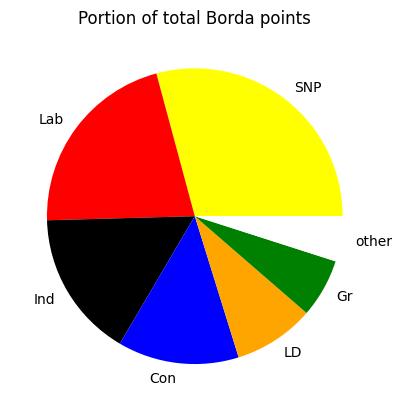

In [112]:
plt.pie(scores, labels = top_parties, colors=colors)
plt.title('Portion of total Borda points')
plt.savefig("plots/pie.jpg", dpi = 600)

In [108]:
# Create table showing the number of number of total first-place-votes (over all elections)
# received by each major party.

data_dict = {party_code:0 for party_code in top_parties}
filename_list = glob.glob("scot-elex/**/*.csv")

for filename in filename_list:
    num_cands, election, cand_names, location = csv_parse(filename)
    party_list = party_abrevs(cand_names)
    for ballot, weight in election.items():
        party = party_list[ballot[0]-1]
        if party in ['SNP', 'Lab', 'Ind', 'Con', 'LD', 'Gr']:
            data_dict[party]+=weight
        else:
            data_dict['other']+=weight

total = sum(data_dict.values())
for party in data_dict:
    data_dict[party] /= total

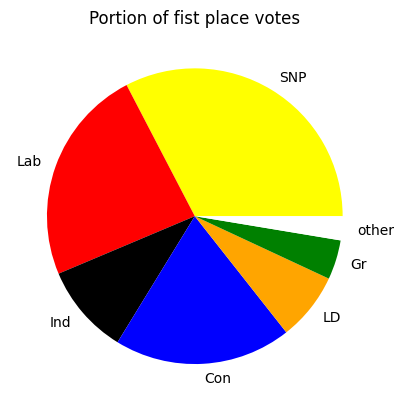

In [111]:
plt.pie(data_dict.values(), labels = top_parties, colors=colors)
#plt.title("Portion of first place votes")
plt.title('Portion of fist place votes')
plt.savefig("plots/pie_2.jpg", dpi = 600)

In [50]:
# add a column 'portion_of_graph_covered'
def F(n):
    return math.floor(np.exp(1)*math.factorial(n)-1)

ls = []
for count in range(len(df)):
    num_cands = df['num_cands'][count]
    num_bal = df['num_unique_ballots'][count]
    portion = num_bal/F(num_cands)
    ls.append(portion)
df['portion_of_graph_covered'] = ls

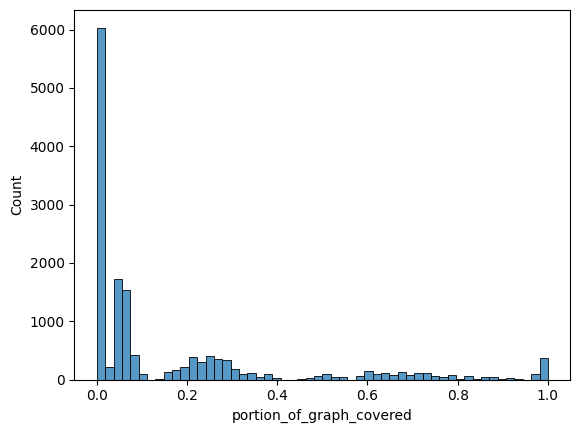

In [53]:
fig = sns.histplot(data = df, x = 'portion_of_graph_covered')
fig.figure.savefig("plots/portion_portion_of_graph_covered.jpg", dpi = 600)

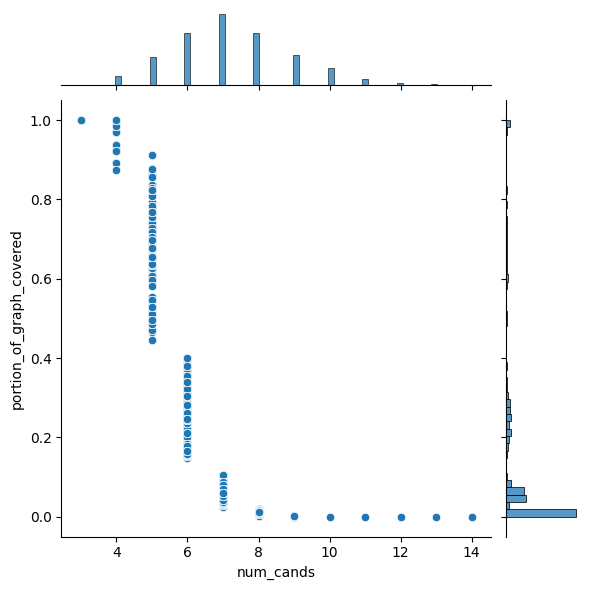

In [68]:
fig = sns.jointplot(data = df, x = 'num_cands', y = 'portion_of_graph_covered')
fig.figure.savefig('plots/num_cands_vs_portion_covered.jpg', dpi=600)

In [56]:
# find the avg portion of graph covered among elections with each choice of num_cands

for count in range(13):
    d = df[df['num_cands'] == count]
    p = np.mean(d['portion_complete_ballots'])
    print(count,p)

0 nan
1 nan
2 nan
3 0.008598117831063361
4 0.009300748501400434
5 0.026596452277013908
6 0.05073919821196347
7 0.06560199490007185
8 0.0729682689459772
9 0.07062990452593518
10 0.0687691370410793
11 0.04889971163959394
12 0.05545848066503088


In [67]:
# Create table showing the number of elections in which each major party ran each number of candidates.

top_parties = ['SNP', 'Lab', 'Ind', 'Con', 'LD', 'Gr']
data = np.zeros((6,11))
filename_list = glob.glob("scot-elex/**/*.csv")

for filename in filename_list:
    num_cands, election, cand_names, location = csv_parse(filename)
    party_list = party_abrevs(cand_names)
    for party_index in range(len(top_parties)):
        party = top_parties[party_index]
        count = party_list.count(party)
        data[party_index,count] +=1

trunc_data = data[:,:8]
pf = pd.DataFrame(trunc_data, index = top_parties, columns=range(8))
pf.to_csv('tables\How_many_candidates_does_the_party_run.csv')
pf


,0,1,2,3,4,5,6,7
SNP,32.0,322.0,658.0,57.0,1.0,0.0,0.0,0.0
Lab,166.0,465.0,405.0,34.0,0.0,0.0,0.0,0.0
Ind,427.0,323.0,153.0,83.0,31.0,25.0,13.0,9.0
Con,55.0,867.0,138.0,10.0,0.0,0.0,0.0,0.0
LD,332.0,700.0,36.0,2.0,0.0,0.0,0.0,0.0
Gr,508.0,562.0,0.0,0.0,0.0,0.0,0.0,0.0


Study of Medoids

In [76]:
# Next create a new column, pmeds, that contain the Borda medoids with each candidate replaced by her party

ls = []
for index in df.index:
    medoids = df['medoids_B'][index]
    party_names = df['parties'][index]
    M = [[],[]]
    for n in range(2):
        med = medoids[n]
        M[n] = [Party_code_and_fullname(party_names[x])[0] for x in med]
    if 'SNP' in M[0]:
        Dm = {0:tuple(M[0]),1:tuple(M[1])}
    else:
        Dm = {0:tuple(M[1]),1:tuple(M[0])}
    ls.append(Dm)
df['pmeds']=ls

In [77]:
# reset the meanings of df0 and dfs, so they include the newly added columns
df0 = df[df['trial_num'] == 0] 
dfs = df0.dropna(subset = ['slates']) 

In [227]:
dfs[['pmeds','party_codes']]

,pmeds,party_codes
12,"{0: ('SNP', 'SNP'), 1: ('Con', 'Lab')}","{1: 'Lab', 2: 'SNP', 3: 'Con', 4: 'Ind', 5: 'S..."
26,"{0: ('SNP', 'SNP', 'Gr'), 1: ('Con', 'Lab')}","{1: 'API', 2: 'SNP', 3: 'Ind', 4: 'SNP', 5: 'G..."
40,"{0: ('SNP', 'SNP'), 1: ('Lab', 'Lab')}","{1: 'Con', 2: 'LD', 3: 'SFP', 4: 'Lab', 5: 'Gr..."
54,"{0: ('SNP', 'SNP'), 1: ('Con',)}","{1: 'Con', 2: 'LD', 3: 'Lab', 4: 'SNP', 5: 'SN..."
68,"{0: ('SNP', 'SNP', 'SNP'), 1: ('Ind',)}","{1: 'LD', 2: 'SNP', 3: 'Ind', 4: 'Ind', 5: 'SN..."
...,...,...
14922,"{0: ('SNP', 'Lab', 'Lab'), 1: ('Con',)}","{1: 'SNP', 2: 'Lab', 3: 'Lab', 4: 'TUSC', 5: '..."
14936,"{0: ('SNP', 'SNP', 'SNP'), 1: ('Lab', 'Lab')}","{1: 'Ind', 2: 'SNP', 3: 'Lab', 4: 'Ind', 5: 'U..."
14950,"{0: ('SNP', 'SNP', 'SNP'), 1: ('Con', 'Lab', '...","{1: 'SNP', 2: 'SNP', 3: 'Lab', 4: 'Gr', 5: 'Co..."
14964,"{0: ('SNP', 'SNP', 'SNP'), 1: ('Lab', 'Lab')}","{1: 'SNP', 2: 'SNP', 3: 'Lab', 4: 'Con', 5: 'S..."


In [228]:
len(dfs)

1070

In [252]:
# create `df_both` filtering of rows that use MedoidBA method and have SNP and Con both represented in the election 
ls = []
for index in df.index:
    ls.append('Con' in df['party_codes'][index].values() and 'SNP' in df['party_codes'][index].values())
df['SNPCon'] = ls

df_both = df[(df['SNPCon']) & (df['method'] == 'medoBA') & (df['trial_num'] == 1)]
len(df_both), len(dfs)

(1008, 1070)

In [255]:
# How many have SNP in the medoid?
count = 0
for index in df_both.index:
    pmeds = df_both['pmeds'][index]
    if 'SNP' in pmeds[0]:
        count +=1
count, len(df_both)

(956, 1008)

Study elections with very unequal bloc sizes

In [46]:
test = dfs[(dfs['bloc_size']<.2)]
test_files = [( test['num_cands'][index], test['filename'][index], test['slates'][index])
               for index in test.index]
test_files

[(4, 'eilean_siar_2022_ward5.csv', {0: (1, 4), 1: (2, 3)}),
 (4, 'shetland_2017_ward6.csv', {0: (1,), 1: (2, 3, 4)}),
 (6, 'sc_borders_2017_ward10.csv', {0: (3,), 1: (1, 2, 4, 5, 6)}),
 (6, 'sc_borders_2022_ward10.csv', {0: (4,), 1: (1, 2, 3, 5, 6)}),
 (6, 'shetland_2017_ward3.csv', {0: (1, 2, 5), 1: (3, 4, 6)}),
 (6, 'shetland_2022_ward4.csv', {0: (1, 2, 5), 1: (3, 4, 6)}),
 (7, 'orkney_2017_ward2.csv', {0: (5, 6), 1: (1, 2, 3, 4, 7)}),
 (7, 'orkney_2017_ward4.csv', {0: (1, 3, 5), 1: (2, 4, 6, 7)}),
 (7, 'shetland_2012_ward3.csv', {0: (5, 6), 1: (1, 2, 3, 4, 7)}),
 (7, 'shetland_2012_ward6.csv', {0: (2, 5), 1: (1, 3, 4, 6, 7)}),
 (8, 'highland_2012_ward12.csv', {0: (1, 2, 3), 1: (4, 5, 6, 7, 8)}),
 (8, 'highland_2012_ward8.csv', {0: (3, 4), 1: (1, 2, 5, 6, 7, 8)}),
 (8, 'orkney_2012_ward1.csv', {0: (1, 3), 1: (2, 4, 5, 6, 7, 8)}),
 (8, 'shetland_2022_ward3.csv', {0: (1, 4, 7), 1: (2, 3, 5, 6, 8)})]

{0: (3,), 1: (1, 2, 4, 5, 6)}


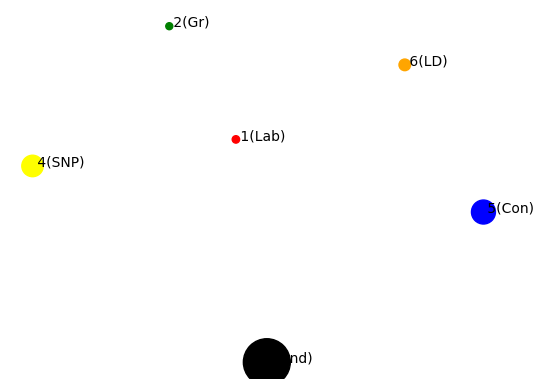

In [49]:
(n, filename, slates) = test_files[2]
file = f"scot-elex/{n}_cands/{filename}"
num_cands, election, cand_list, ward = csv_parse(file)
party_names = party_abrevs(cand_list)
print(slates)
Candidate_MDS_plot(election,party_names=party_names, party_colors='Auto')
C = Slate_cluster(election)

{0: (1, 4), 1: (2, 3)}


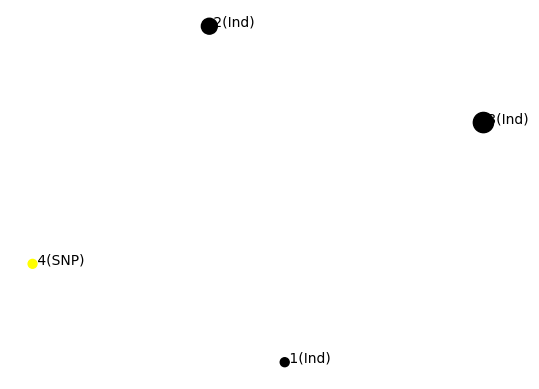

{0: (1,), 1: (2, 3, 4)}


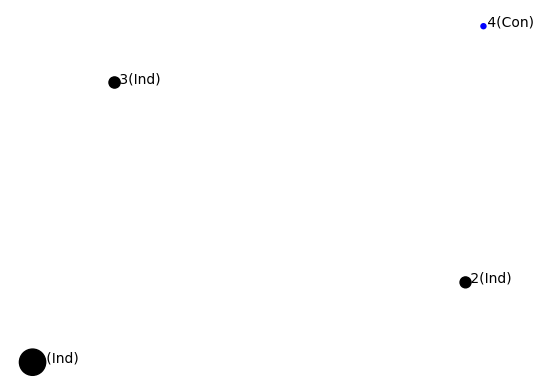

{0: (3,), 1: (1, 2, 4, 5, 6)}


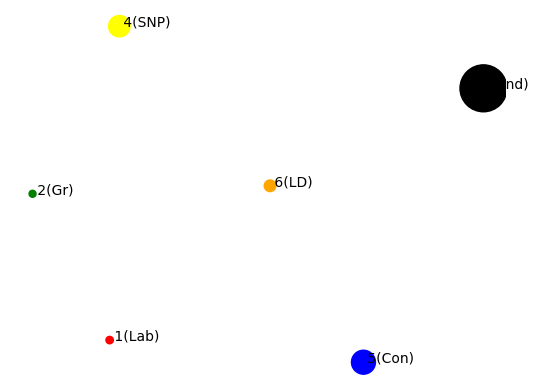

{0: (4,), 1: (1, 2, 3, 5, 6)}


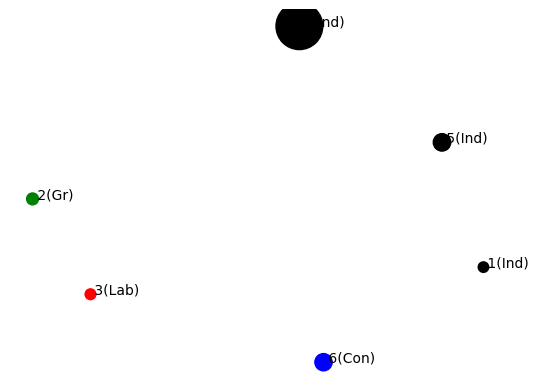

{0: (1, 2, 5), 1: (3, 4, 6)}


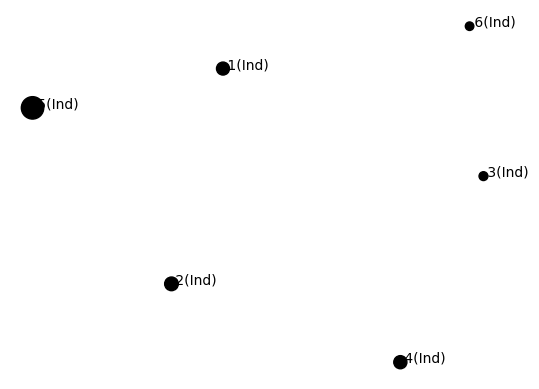

{0: (1, 2, 5), 1: (3, 4, 6)}


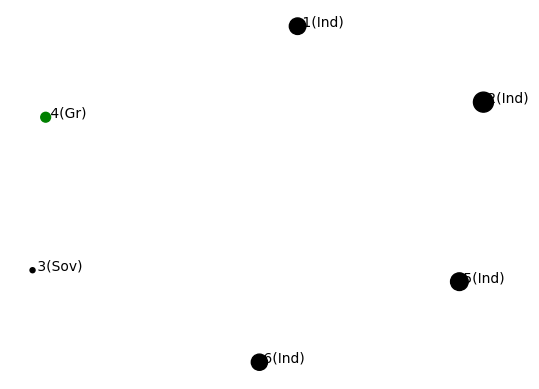

{0: (5, 6), 1: (1, 2, 3, 4, 7)}


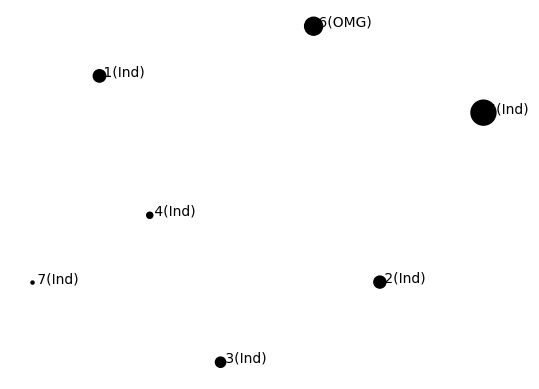

{0: (1, 3, 5), 1: (2, 4, 6, 7)}


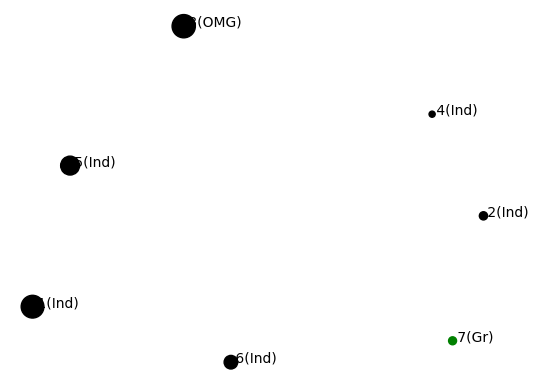

{0: (5, 6), 1: (1, 2, 3, 4, 7)}


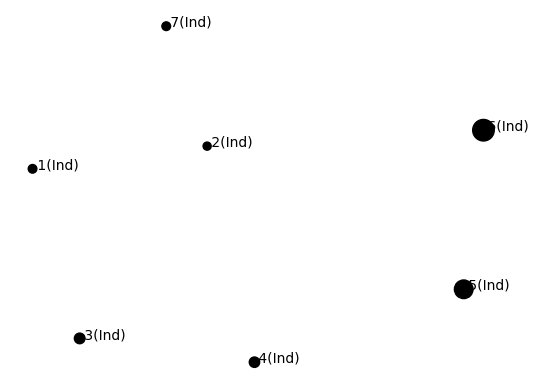

{0: (2, 5), 1: (1, 3, 4, 6, 7)}


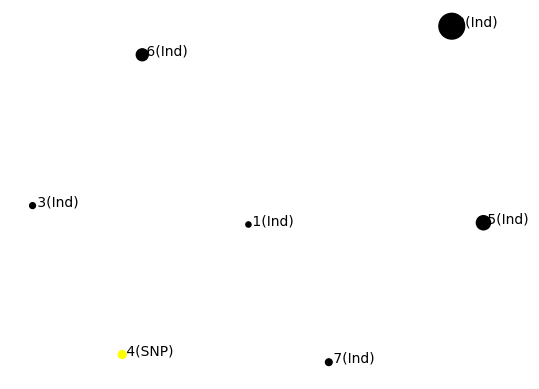

{0: (1, 2, 3), 1: (4, 5, 6, 7, 8)}


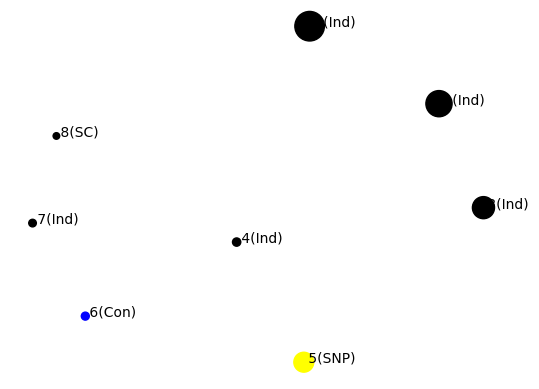

{0: (3, 4), 1: (1, 2, 5, 6, 7, 8)}


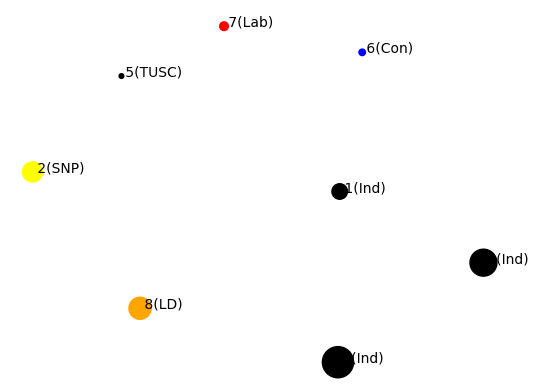

{0: (1, 3), 1: (2, 4, 5, 6, 7, 8)}


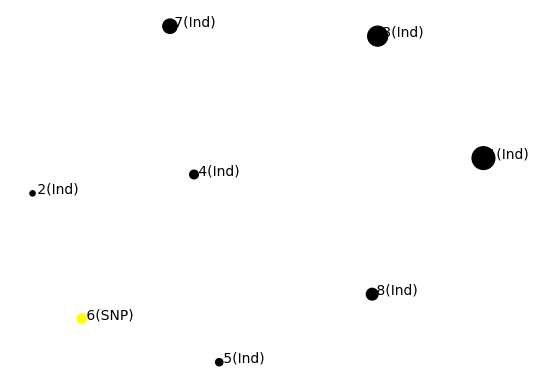

{0: (1, 4, 7), 1: (2, 3, 5, 6, 8)}


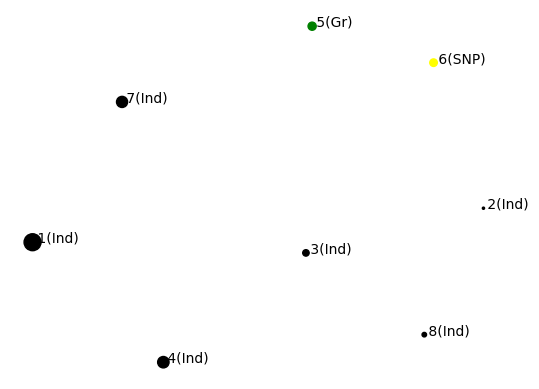

In [48]:
for (n, filename, slates) in test_files:
    file = f"scot-elex/{n}_cands/{filename}"
    num_cands, election, cand_list, ward = csv_parse(file)
    party_names = party_abrevs(cand_list)
    print(slates)
    Candidate_MDS_plot(election,party_names=party_names, party_colors='Auto')

In [200]:
num_cands, election, cand_list, ward = csv_parse('scot-elex/4_cands/shetland_2017_ward6.csv')

In [202]:
C = kmeans(election, proxy='Borda', borda_style='avg')

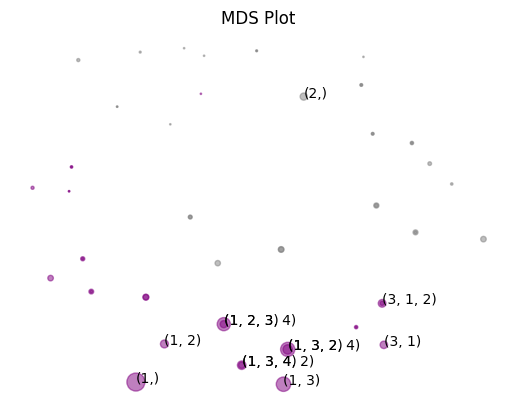

In [212]:
Ballot_MDS_plot(election, C, threshold=1, label_threshold=20)

In [213]:
Summarize_election(election, C, size = 30)

This election has: 4 candidates, 995 ballots, 56 distinct ballots, 2.54 avg ballot length.
 CLUSTER 1: 190 ballots, 29 distinct ballots, 2.59 avg ballot length. 
 CLUSTER 2: 805 ballots, 27 distinct ballots, 2.53 avg ballot length. 
Top ballots:
 	 169 votes for (1,). 
 	 108 votes for (1, 3). 
 	 105 votes for (1, 3, 2). 
 	 90 votes for (1, 2, 3). 
 	 46 votes for (1, 3, 2, 4). 
 	 38 votes for (1, 3, 4). 
 	 33 votes for (1, 2). 
 	 31 votes for (3, 1, 2). 
 	 29 votes for (3, 1). 
 	 27 votes for (1, 2, 3, 4). 
 	 27 votes for (2,). 
 	 21 votes for (1, 3, 4, 2). 
 	 19 votes for (1, 2, 4, 3). 
 	 17 votes for (2, 1, 3). 
 	 16 votes for (1, 4). 
 	 16 votes for (3,). 
 	 15 votes for (1, 2, 4). 
 	 15 votes for (2, 1). 
 	 14 votes for (2, 1, 3, 4). 
 	 14 votes for (2, 3, 1). 
 	 13 votes for (3, 2, 1). 
 	 12 votes for (1, 4, 3, 2). 
 	 9 votes for (1, 4, 2, 3). 
 	 9 votes for (3, 1, 2, 4). 
 	 8 votes for (2, 1, 4, 3). 
 	 7 votes for (2, 3). 
 	 7 votes for (2, 3, 1, 4). 
 	 

In [270]:
# check which clustering methods produce the longest medoids

method_list = df['method'].unique()
summed_medoid_size = {method:0 for method in method_list}
num_elections = {method:0 for method in method_list}

for index in df.index:
    method = df['method'][index]
    medoids = df['medoids_B'][index]
    summed_medoid_size[method] += len(medoids[0])+len(medoids[1])
    num_elections[method] += 1
avg_medoid_size = {method: round(summed_medoid_size[method]/num_elections[method],2) for method in method_list}

avg_medoid_size

{'meanBC': 4.56,
 'meanBA': 4.54,
 'meanH': 4.53,
 'medoBC': 4.59,
 'medoBA': 4.35,
 'medoH': 4.37,
 'slate': 4.7}

In [33]:
df['centers']

0       [[2.2915414340918456, 7.707599828252526, 0.681...
1       [[5.930468516860638, 3.4218143837660566, 6.041...
2       [[-0.4079123826553346, 0.13679034421099676, -0...
3                                    {0: (3,), 1: (2, 5)}
4                                  {0: (3, 1), 1: (2, 5)}
                              ...                        
7485    [[0.018708425720621577, -0.15285476718403443, ...
7486                            {0: (4, 6, 5), 1: (1, 2)}
7487                               {0: (4, 6), 1: (1, 2)}
7488                            {0: (1, 2), 1: (4, 6, 5)}
7489               {0: (1,), 1: (2, 3, 4, 5, 6, 7, 8, 9)}
Name: centers, Length: 7490, dtype: object

In [34]:
df['centers'][0]

array([[2.29154143, 7.70759983, 0.68140833, 2.25118076, 7.6019751 ,
        1.60025762, 0.52769429, 3.17518248, 1.72133963, 0.2657793 ],
       [4.27531355, 0.38972163, 4.5965127 , 3.08901805, 0.34811869,
        2.74334659, 0.76170083, 1.51085959, 3.23738146, 0.21290915]])